## Otorowiri Transect

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import sys
import os
import pickle
import flopy
import geopandas as gpd
from shapely.geometry import LineString,Point,Polygon,MultiPolygon,MultiPoint,shape

%load_ext autoreload
%autoreload 2

import loopflopy
import loopflopy.utils as utils

modules = utils.list_modules(loopflopy)
#for module in modules: print(module)

os.getcwd()

loopflopy.__file__

'c:\\users\\00105295\\projects\\loopflopy\\loopflopy\\__init__.py'

### 1. Setup Project

In [2]:
name = 'otorowiri_transect'
workspace = '../modelfiles/'
results = '../results/'
figures = '../figures/'
triexe = '../exe/triangle.exe'
mfexe = '../exe/mf6.exe'

from loopflopy.project import Project
project = Project(name, workspace, results, figures, triexe, mfexe)
project.crs = 28350  # UTM zone 50S, EPSG:28350

### 2. Structural Model

#### 2.1 Bounding box

In [3]:
# A bounding box for structural model
x0, x1 = 320000, 400000
y0, y1 = 6670000, 6780000
z0, z1 = -1500, 400
bbox = [(x0, y0, z0), (x1, y1, z1)]

from loopflopy.spatial_routines import make_bbox_shp
crop_polygon = make_bbox_shp(x0, x1, y0, y1, crs=project.crs, fname = '../data/data_shp/structuralmodel.shp')

#### 2.2 Create the structural model object

In [4]:
# Create Structural Model object
geodata_fname = '../data/data_geology/bore_data_Otorowiri.xlsx'
data_sheetname = 'geodata_elevation'
strat_sheetname = 'strat'
from loopflopy.structuralmodel import StructuralModel
#spatial and bbox come from the spatial module, excel file and sheet names are user defined
structuralmodel = StructuralModel(bbox, geodata_fname, data_sheetname, strat_sheetname)

#### 2.3 Clip the DEM to the structural model

In [5]:
# Clip DEM to structuralmodel
import process_dem

original_asc_path     = '../data/data_elevation/rasters_COP30/output_hh.asc'
crop_polygon_shp_path = '../data/data_shp/structuralmodel.shp'
output_tif_path       = '../data/data_dem/structuralmodel_dem.tif'
#process_dem.model_DEM(original_asc_path, crop_polygon_shp_path, output_tif_path) #only need to do once! About 5min

from loopflopy.dem import DEM
geotiff_fname = '../data/data_dem/structuralmodel_dem.tif'
dem_structural = DEM(geotiff_fname = geotiff_fname)
#dem_structural.plot_geotiff()

#### 2.4 Resample DEM to raster mesh

No special cells
EPSG:28350
EPSG:28350


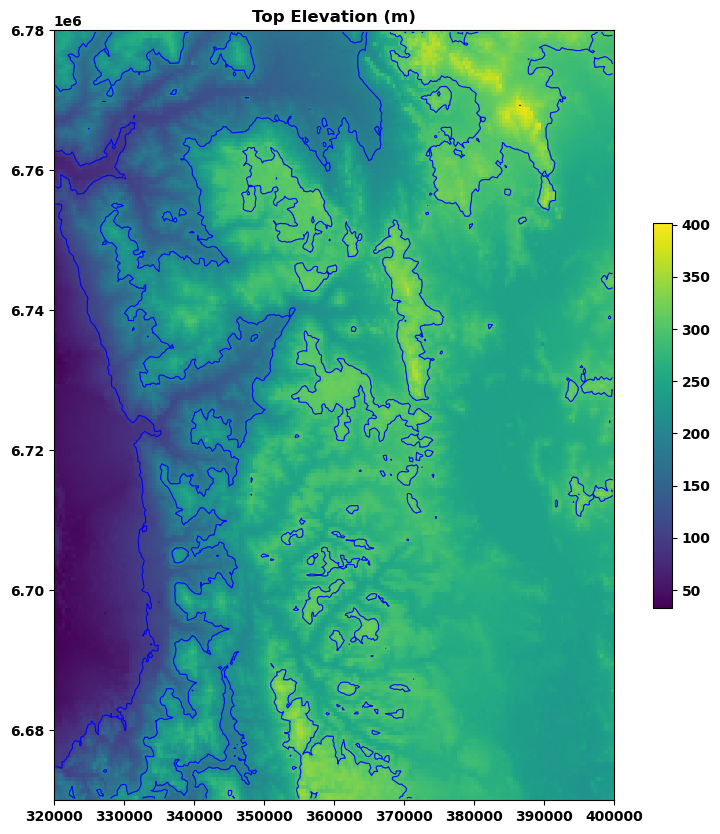

In [6]:
# Resample DEM to raster mesh
from loopflopy.mesh_routines import create_structured_mesh
dem_grid = create_structured_mesh(bbox, ncol = 200, nrow = 200, crs = project.crs)

dem_structural.resample_topo(dem_grid, output_fname = '../modelfiles/structural_topo.pkl') # only need to run when mesh changes. Take 1-2 minutes
dem_structural.load_topo(fname = '../modelfiles/structural_topo.pkl')
dem_structural.plot_topo(dem_grid, levels = [0, 100, 200, 300, 400, 500, 600, 700])

structuralmodel.topo = dem_structural.topo
structuralmodel.mesh = dem_grid

#### 2.5 Process structural model from spreadsheet

In [7]:
import process_structural

process_structural.geo_boundaries(project, structuralmodel, crop_polygon, simplify_tolerance =1000, node_spacing = 2000)
process_structural.prepare_strat_column(structuralmodel)
process_structural.add_geo_boundaries(structuralmodel)
process_structural.elevation_fill_all(structuralmodel) #this will fill all the boreholes with DEM elevations
#process_structural.elevation_fill_unknown(structuralmodel) #this will fill only the boreholes with no elevation data
process_structural.prepare_geodata(structuralmodel)
process_structural.create_structuralmodel(structuralmodel)


#structuralmodel.model.to_file('../modelfiles/structuralmodel') #pickle the model to send to people
#structuralmodel.data.to_excel('../modelfiles/structuraldata.xlsx', index=False) # Check the data used for structural model
#structuralmodel.strat.to_excel('../modelfiles/structuralstrat.xlsx', index=False) # Check the stratigraphy used for structural model

     sequence    unit    R    G    B   val  lithid Thickness  iconvert    hk  \
0      Ground  Ground  255  255  255     0      -1         -       NaN   NaN   
1  Yarragadee      Kp  172  186  242   124       0       NaN       1.0   8.0   
2  Yarragadee     Kpo  117  128  229   100       1       NaN       0.0   0.1   
3  Yarragadee      Jy  198  217  240 -1000       2       NaN       0.0  10.0   

     vk       ss    sy     Unnamed: 13  
0   NaN      NaN   NaN             NaN  
1   0.1  0.00010  0.10  hk should be 8  
2   0.1  0.00001  0.01             NaN  
3  10.0  0.00001  0.20             NaN  

Updated DataFrame with geo_boundaries written to new sheet: 'geo_boundaries' in file: ../data/data_geology/bore_data_Otorowiri.xlsx
Replaced elevation values for 167 points from DEM.
Updated elevations written to sheet: 'geodata_elevation' in ../data/data_geology/bore_data_Otorowiri.xlsx
167 valid elevation points retained for further processing.



Updated DataFrame written to new sheet: 'structuralmodel_data' in file: ../data/data_geology/bore_data_Otorowiri.xlsx
1.6.14


c:\Users\00105295\AppData\Local\anaconda3\envs\loopflopy\Lib\site-packages\LoopStructural\modelling\core\geological_model.py:646: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap, n_units)


#### 2.6 Plot cross-sections of the structural model

In [8]:
#model_extent = [(347905.244, 6728488.330), (349057.427, 6729166.087)] # SMALL SCALE
model_extent = [(345000, 6701500),(380000, 6703000)]  # LARGE SCALE
x0, y0 = model_extent[0][0], model_extent[0][1]
x1, y1 = model_extent[1][0], model_extent[1][1]

# DONGARA LINE - 6750000
# ENEABBA LINE - 6700000

plot = False
if plot:
    nh, nv = 100, 100
    dz = [5, 5, 10, 15] # spacing of bedding layers
    x0, y0 = model_extent[0][0], model_extent[0][1]
    x1, y1 = model_extent[1][0], model_extent[1][1]
    z0, z1 = -300, 300
    structuralmodel.plot_transect(x0, x1, y0, y1, z0, z1, nh, nv, dz, figsize = (12, 1.5),)

### 5. Spatial

#### 5.1 Set basics as spatial objects

POLYGON ((361337.20725018514 6735522.680110534, 361318.55532478204 6735525.34676506, 361300.2371096979 6735529.756794962, 361282.41518154956 6735535.871060632, 361265.24771234096 6735543.635297142, 361248.8870656651 6735552.98059585, 360589.151451948 6735972.229061367, 360574.4827576252 6735982.500582804, 359975.5522891828 6736443.188638042, 359972.66517840134 6736445.4518035585, 359627.74982986867 6736720.970266216, 359160.85397186875 6737035.591168093, 358646.0471174668 6737374.582637623, 358631.7419482652 6737384.935738192, 358618.4057506354 6737396.510296069, 358606.14248842536 6737409.21608047, 358595.04776129295 6737422.954042004, 358178.78923114884 6737987.677366506, 358168.802181669 6738002.582821196, 358160.19113841595 6738018.3233317, 357803.21527111484 6738746.661997532, 357802.45015107194 6738748.240553889, 357439.64677841234 6739505.1979318485, 356985.1587132632 6739946.094619135, 356649.4186185305 6740144.445396702, 355987.0582307656 6740394.382825348, 355969.0571409932 6

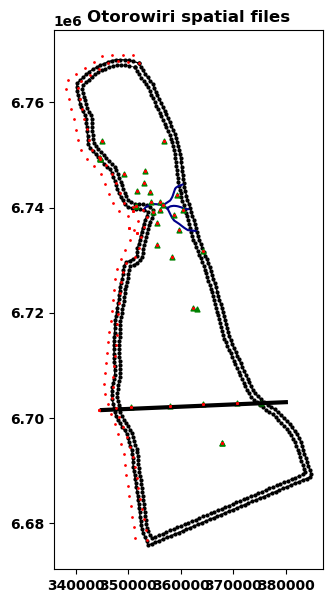

In [9]:
from loopflopy.spatial import Spatial
spatial = Spatial(epsg = project.crs)

import process_spatial
process_spatial.model_boundary(spatial, boundary_buff = 1000, simplify_tolerance = 0, node_spacing = 800)
process_spatial.geo_bores(spatial)
process_spatial.obs_bores(spatial)
process_spatial.pump_bores(spatial)
process_spatial.arrow(spatial, node_spacing = 300, buffer_distance = 200, threshold = 100)
process_spatial.head_boundary_transect(spatial, x0, x1, y0, y1)
#process_spatial.small_creek(spatial, buffer_distance = 200, node_spacing = 200, threshold = 100)
#process_spatial.sand_plain_creek(spatial, buffer_distance = 200, node_spacing = 200, threshold = 100)
#process_spatial.rivers(spatial, node_spacing = 200, buffer_distance = 200, threshold = 100)
#process_spatial.fault_trace(spatial, node_spacing = 300, buffer_distance = 200, threshold = 100)
# Uncomment the next line to process outcrop polygons, but it is not needed for the model
#process_spatial.outcrop(spatial, node_spacing = 200, buffer_distance = 200, threshold = 100)

spatial.xsection_names = ['A', 'B', 'C']
spatial.xsections = [
                     [(340000, 6702000),(385000, 6703000)], 
                     [(340000, 6730000),(365000, 6740000)],
                     [(345000, 6780000),(370000, 6680000)]
                     ]

#extent = [[330000, 370000],[6740000, 6770000]] #[[342000, 370000],[6725000, 6745000]] # extent[[x0,x1], [y0,y1]]
extent = [[330000, 370000],[6680000, 6770000]]
process_spatial.plot_spatial(spatial, structuralmodel,
                 labels = False, # Bore ids
                 obsbores = False, 
                 pumpbores = False, 
                 geobores = True, 
                 arrow = True, # Just arrowsmith
                 small_creek = False,
                 sand_plain = False,
                 fault_trace = False,
                 structuralmodel_data = True,
                 xsections = False,
                 transect_coords = model_extent
                 #extent = extent # Just hash out to see the whole model
                 ) 

In [10]:
m = spatial.obsbore_gdf.explore()#location=[-31.4, 115.8], zoom_start=11, popup = 'ID')
#m = folium.Map(location=[52.0, 4.0], zoom_start=6) 
spatial.model_boundary_gdf.explore(m=m, fill = False)
#spatial.faults_gdf.explore(m=m, color = 'red')

### Meshing for transect flow model

In [11]:
# This makes a mesh (in plan) for the model and also 
# locates the cell numbers for special packages like CHD, GHB
special_cells = {'ghb': ['west',],} 
                 #'chd': ['east',]}

from loopflopy.mesh import Mesh
mesh = Mesh(plangrid = 'transect', special_cells = special_cells) # special cells to identify as arguements 

x0, x1 = model_extent[0][0], model_extent[1][0]
y0, y1 = model_extent[0][1], model_extent[1][1]
transect_length = ((x1 - x0)**2 + (y1 - y0)**2)**0.5
delc = 200 # row width (doesnt matter as in transect)

# Irregularly spaced columns to refine around fault
segments = 2#5
dx = [150, 150]# [100, 20, 100, 20, 100] # Spacing of transect cells
seg_notches = [x0, x0 + 500, x1]#[spatial.x0, 363000, 365000, 371000, 373000, spatial.x1]
seg_x_length = [seg_notches[i+1] - seg_notches[i] for i in range(len(seg_notches)-1)]
ncol_per_seg = [int(seg_x_length[i]/dx[i]) for i in range(len(seg_x_length))]
delr = [seg_x_length[i]/ncol_per_seg[i] for i in range(len(seg_x_length)) for _ in range(ncol_per_seg[i])]
delr = np.array(delr)

In [12]:
mesh.create_irregular_mesh_transect(project.crs, x0, x1, y0, y1, delc, delr)
mesh.locate_special_cells(spatial) # KB Needs fixing this to work with transect mesh
print('number of cells in plan = ', mesh.ncpl)
print('Sum of the column thickness = ', np.sum(delr))
print('Transect length = ', transect_length)
print('rotation_angle  = ', mesh.angrot)


Transect length: 35032.128111206715
x0 =  345000  ,y0 =  6701500
x1 =  380000  ,y1 =  6703000
angrot  2.4540316745270756
ncol =  233
Group =  ghb ['west']
flag = 1
number of cells in plan =  233
Sum of the column thickness =  35000.0
Transect length =  35032.128111206715
rotation_angle  =  2.4540316745270756


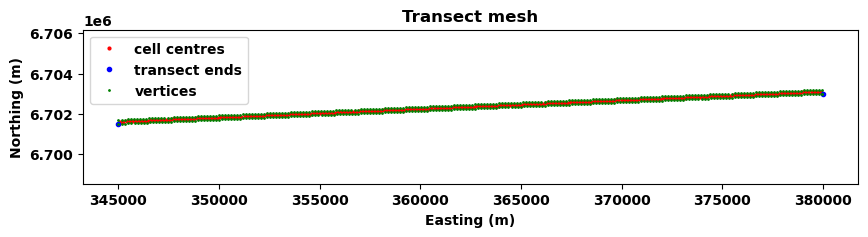

In [13]:
# This plots the cell centres (red), vertices (green) and transect ends (blue)
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(mesh.xcenters, mesh.ycenters, 'ro', ms= 2., label = 'cell centres')
ax.plot(mesh.x0, mesh.y0, 'bo', ms = 3., label = 'transect ends')
ax.plot(mesh.x1, mesh.y1, 'bo', ms = 3.)
for ivert in mesh.vertices:
    i, x, y = ivert
    ax.plot(x, y, 'go', ms = 1.)
ax.plot(x, y, 'go', ms = 1., label = 'vertices')
ax.axis('equal')
ax.set_title('Transect mesh')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
#ax.set_ylim([mesh.y0 - 300, mesh.y1 + 50])
ax.legend()

#### 6.3 Overlay DEM over mesh

Clipped GeoTIFF saved to: ../Data/data_dem/Otorowiri_Geomodel_DEM.tif


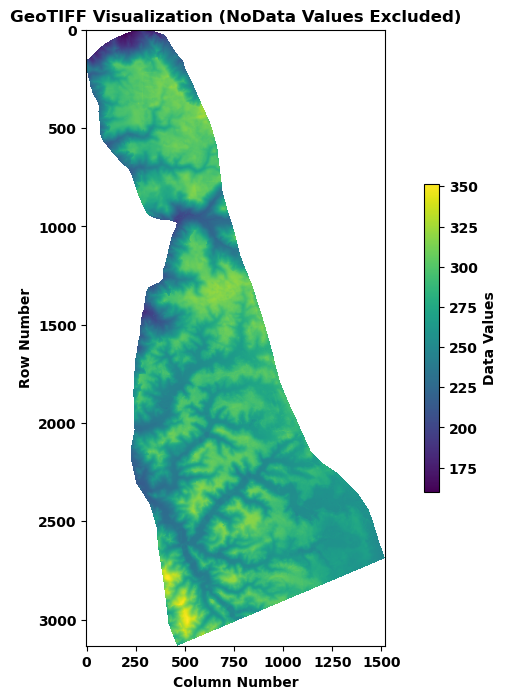

None
EPSG:28350
None
EPSG:28350


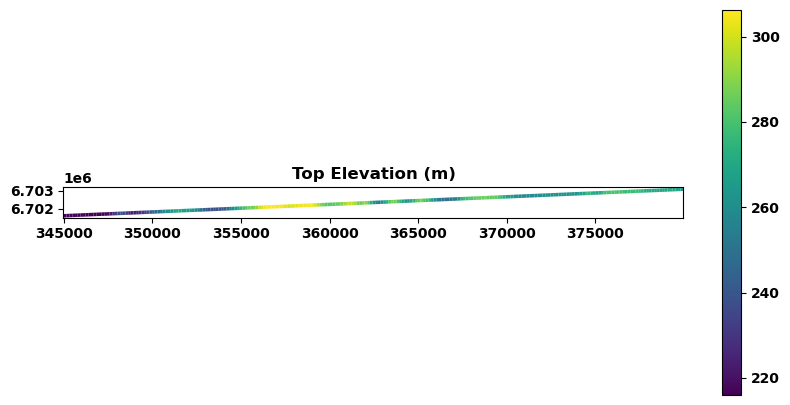

In [14]:
##here clip model to the geological model boundary
original_tiff_path    = '../data/data_dem/structuralmodel_dem.tif' #Otorowiri_Model_DEM.tif'
crop_polygon_shp_path = '../data/data_shp/model_boundary.shp'
output_tiff_path      = '../Data/data_dem/Otorowiri_Geomodel_DEM.tif'
process_dem.crop_geotiff(original_tiff_path, crop_polygon_shp_path, output_tiff_path)

dem_geomodel = DEM(geotiff_fname = output_tiff_path)
dem_geomodel.plot_geotiff()

#resample DEM to mesh
dem_geomodel.resample_topo(mesh, output_fname = '../modelfiles/geomodel_topo.pkl') # only need to run when mesh changes. Take 1-2 minutes
dem_geomodel.load_topo(fname = '../modelfiles/geomodel_topo.pkl')

# This pickles (saves) the topography and plots for visualization
fname = '../data/data_dem/geomodel_topo.pkl'
dem_geomodel.resample_topo(mesh, fname, crop_polygon = False, method="nearest", extrapolate_edges=True,)
dem_geomodel.load_topo(fname) # Saves to instance dem.topo
dem_geomodel.plot_topo(mesh, levels = np.arange(-50, 300, 50))

### 7. Geomodel

In [15]:
# Set up Geomodel (lithological block model of cells)
scenario = 'transect'
z0, z1 = -300., 400. # shouold really be 100, but voxel mesh does not accommodate empty cells yet
nlay = 30 
from loopflopy.geomodel_voxel import Geomodel
geomodel = Geomodel(scenario, mesh, structuralmodel, z0, z1, nlay, transect = True)         # VOX - Regular layers


In [16]:
geomodel.evaluate_structuralmodel()

Structural model ---> Block Geomodel  transect  ...

0. Creating xyz array... 
   len(xyz) =  6990


ERROR: 2025-10-28 14:56:11,306: geological_model.py:1559 -- Model does not contain Ground
ERROR: 2025-10-28 14:56:11,337: geological_model.py:1590 -- Model does not contain Ground


In [17]:
surface = np.ones((mesh.nrow, mesh.ncol))*195.# dem_geomodel.topo 
geomodel.find_geolayers(surface)
geomodel.make_geomodel(nlg = 1)


2. Find geomodel layer elevations...
   nlay =  30
   ncpl =  233
   nlg number of geo layers =  3
   botm_geo_shape (3, 233)
   Time taken Block 2 (Find geological model layer elevations) 0.013452

3. Creating flow model layers and idomain...
   Time taken Block 3 (Creating flow model layers) 0.007006

3. Calculating cellids and gradients...
   Time taken Block 4 gradients=  0.003001


In [18]:
# GEOMODEL DETAILS:
print('Transect extent in x direction: ', spatial.x0, ' to ', spatial.x1)
print('Transect extent in z direction: ', geomodel.z0, ' to ', geomodel.z1)
print('Number of columns = ', geomodel.ncpl, ', Number of layers = ', geomodel.nlay)
print('ncol = ', mesh.ncol)
print('first column width (delr) = ', mesh.delr[0])
print('nlay = ', geomodel.nlay)
print('lay thickness = ', geomodel.dz)


Transect extent in x direction:  340221.111300781  to  384802.4286744433
Transect extent in z direction:  -300.0  to  400.0
Number of columns =  233 , Number of layers =  30
ncol =  233
first column width (delr) =  166.66666666666666
nlay =  30
lay thickness =  23.333333333333332


(np.float64(345078.97512414557), np.float64(345078.97512414557))

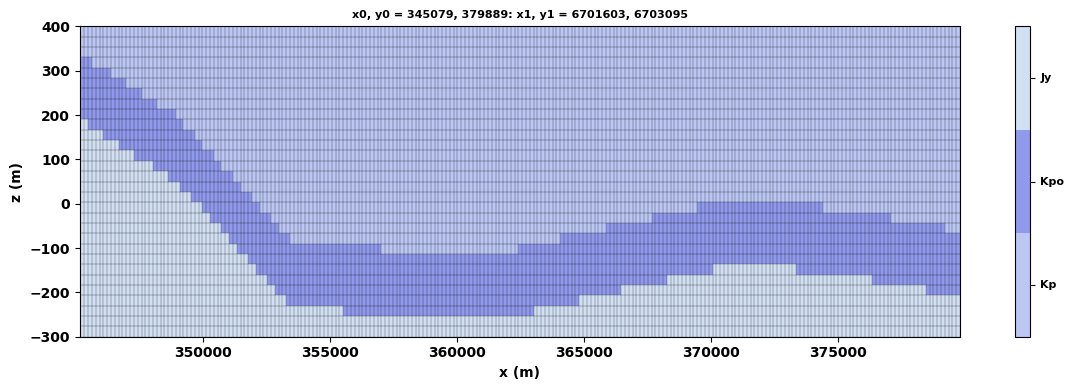

In [19]:
geomodel.geomodel_transect_lith(structuralmodel, mesh, 
                                x0 = mesh.vgrid.xcellcenters[0], 
                                x1 = mesh.vgrid.xcellcenters[-1], 
                                y0 = mesh.vgrid.ycellcenters[0],
                                y1 = mesh.vgrid.ycellcenters[-1],
                                z0 = z0, z1 = z1) 

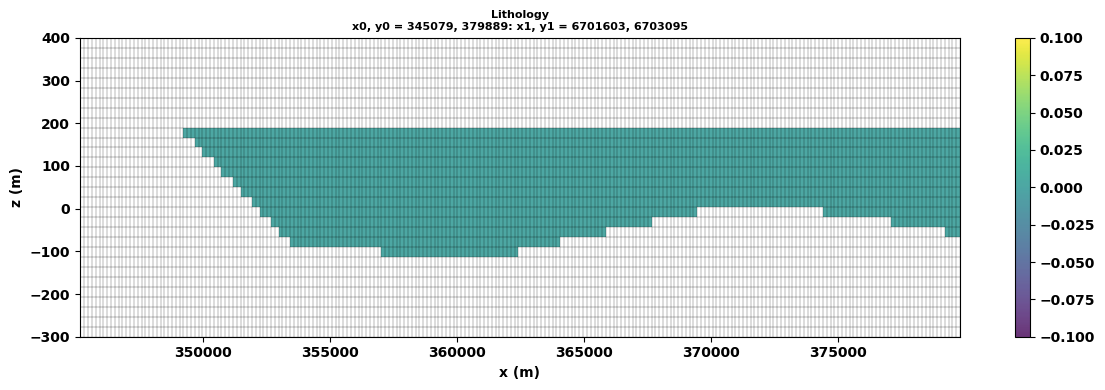

In [20]:
geomodel.geomodel_transect_array(array = np.ma.masked_where(geomodel.idomain == 0, geomodel.lith),
                                 title = "Lithology", 
                                 grid = True,
                                 #x0 = 370000, x1 = 373000,
                                 #vmin = -20, vmax = 20)
                                 #vmin = array.min(), vmax = array.max()
                                 )

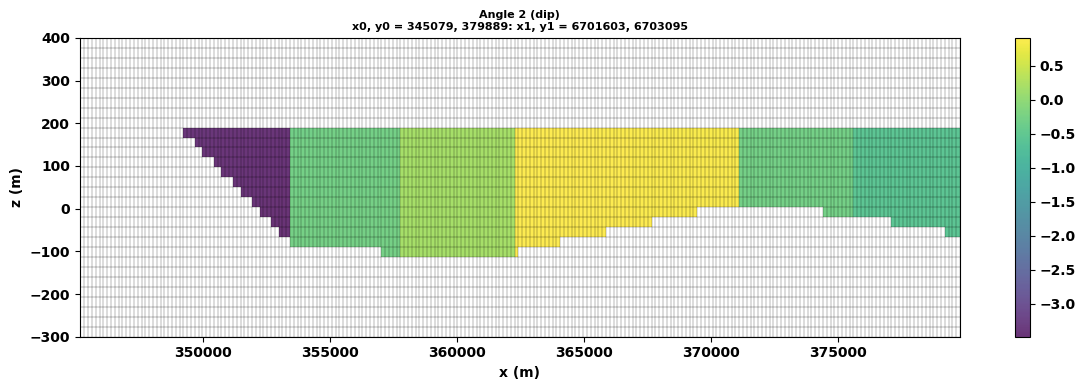

In [21]:
geomodel.geomodel_transect_array(array = np.ma.masked_where(geomodel.idomain == 0, geomodel.ang2),
                                 title = "Angle 2 (dip)", 
                                 grid = True,
                                 #x0 = 370000, x1 = 373000,
                                 #vmin = -20, vmax = 20)
                                 #vmin = array.min(), vmax = array.max()
                                 )

#### Properties

In [113]:
# FILL CELL PROPERTIES
props = pd.read_excel(structuralmodel.geodata_fname, sheet_name = structuralmodel.strat_sheetname)
props = props.drop(index=[0]).reset_index()#inplace=True) # drop first row as it is ground
geomodel.hk_perlay = [10, 0.00001, 0.00001] #props.hk.tolist()
geomodel.vk_perlay = [0.1, 0.00001, 0.00001] #props.vk.tolist()
geomodel.ss_perlay = [0.00001, 0.00001, 0.00001] #props.ss.tolist()
geomodel.sy_perlay = [0.1, 0.1, 0.1] #props.sy.tolist()
geomodel.iconvert_perlay = [1, 0, 0] #props.iconvert.tolist()
geomodel.fill_cell_properties(mesh)


   Time taken Block 5 Fill cell properties =  0.001


In [114]:
non_zero_mask = geomodel.idomain != 0

# Use argmax to find the first True (non-zero) in each column
first_nonzero_layer = np.argmax(non_zero_mask, axis=0)
# If a column has all zeros, argmax returns 0, which may be misleading
# So we can mask those explicitly:
has_nonzero = np.any(non_zero_mask, axis=0)
first_nonzero_layer[~has_nonzero] = -1  # or np.nan if you prefer floats

top_lays = first_nonzero_layer
top_lays
geomodel.idomain[0,28]

np.float64(0.0)

In [115]:
from process_transect_inputs import Inputs
inputs = Inputs()

inputs.process_ic(geomodel, mesh)
inputs.process_rch(geomodel, mesh, top_lays)
inputs.process_ghb(geomodel, props, mesh)
#inputs.process_chd_transect(geomodel, props, mesh)

GHB cell (9, np.int64(28)) at layer 9, icpl 28, head 231.0, K 8.0, conductance 8000.0
GHB cell (9, np.int64(29)) at layer 9, icpl 29, head 231.0, K 8.0, conductance 8000.0
GHB cell (9, np.int64(30)) at layer 9, icpl 30, head 231.0, K 8.0, conductance 8000.0
GHB cell (9, np.int64(31)) at layer 9, icpl 31, head 231.0, K 8.0, conductance 8000.0
GHB cell (10, np.int64(31)) at layer 10, icpl 31, head 231.0, K 8.0, conductance 8000.0
GHB cell (9, np.int64(32)) at layer 9, icpl 32, head 231.0, K 8.0, conductance 8000.0
GHB cell (10, np.int64(32)) at layer 10, icpl 32, head 231.0, K 8.0, conductance 8000.0
GHB records:  [[(9, np.int64(28)), 231.0, 100000000], [(9, np.int64(29)), 231.0, 100000000], [(9, np.int64(30)), 231.0, 100000000], [(9, np.int64(31)), 231.0, 100000000], [(10, np.int64(31)), 231.0, 100000000], [(9, np.int64(32)), 231.0, 100000000], [(10, np.int64(32)), 231.0, 100000000]]


#### Observations

In [116]:
'''# Make 50 observation points - 10 spaced equally across, 5 down
# Then add discretisation details (cell ids) to obs points
import process_observations_transect as process_observations
df = process_observations.make_obs_df(mesh, geomodel)
df_boredetails = process_observations.make_obs_gdf(df, geomodel, mesh, spatial)

# Make package arrays
from loopflopy.observations import Observations
observations = Observations(df_boredetails)
observations.make_recarray()
# observations.gdf # Unhash this line to show the spreadsheet of observation points'''

'# Make 50 observation points - 10 spaced equally across, 5 down\n# Then add discretisation details (cell ids) to obs points\nimport process_observations_transect as process_observations\ndf = process_observations.make_obs_df(mesh, geomodel)\ndf_boredetails = process_observations.make_obs_gdf(df, geomodel, mesh, spatial)\n\n# Make package arrays\nfrom loopflopy.observations import Observations\nobservations = Observations(df_boredetails)\nobservations.make_recarray()\n# observations.gdf # Unhash this line to show the spreadsheet of observation points'

In [117]:
from flowmodel_voxel import Flowmodel
scenario = 'transect_model'
fm = Flowmodel(scenario, project, inputs, mesh, geomodel) # observations,

# Write and run flow model files
sim, gwf = fm.write_flowmodel(chd = False, ghb = True, rch = True, obs = False, xt3d = True, staggered = False)# zbud = True)

fm.run_flowmodel(sim)

Writing simulation and gwf for  transect_model  ...
    xt3d =  True
    staggered =  False
    transient =  False
    mf6 executable expected:  ../exe/mf6.exe
Time taken to write flow model =  0.503898
Running simulation for  transect_model  ...
Model success =  False
run_time =  7.470822

Re-writing IMS - Take 2 (SOMEWHAT MORE AGGRESSIVE)
Model success2 =  False

Re-writing IMS - Take 3 (VERY AGGRESSIVE)
Model success3 =  False


In [118]:
head_array = np.ma.masked_where(geomodel.idomain == 0, fm.head[:,0,:])

fm.plot_transect(mesh, 
                 geomodel, 
                 array = head_array,
                 title = 'Hydraulic Head (Hk:Vk = 10 to 1)',
                 #x0 = 370000, x1 = 373000,
                 grid = False, 
                 contours = True,
                 levels = np.arange(220, 300, 2), # Only need to include if plotting contours
                 vectors = False,
                 normalize = True,
                 kstep = 20, hstep = 3, # IF VECTORS = TRUE, need this line! spacing vertical, horizontal
                 figsize = (12,4),
                 label = 'Head (m)'
                 #vmin = 10, vmax = 25 # can change scale of color
                 )   

AttributeError: 'Flowmodel' object has no attribute 'head'

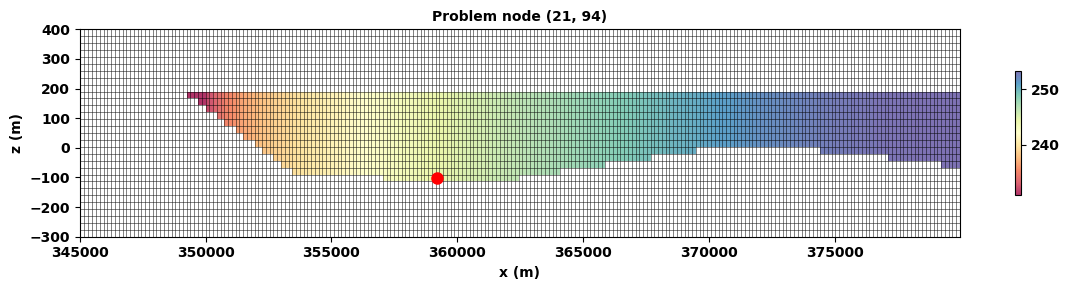

In [ ]:
def plot_problem_node(lay, icpl, fm, array):#, head_array):
    lay, icpl = lay - 1, icpl - 1  # zero based
    fig = plt.figure(figsize = (12,3))
    ax = plt.subplot(111)
    ax.set_title(f'Problem node {lay, icpl}', size = 10)

    xsect = flopy.plot.PlotCrossSection(model=gwf, line={"line": [(x0, y0),(x1, y1)]},
                                        #extent = [x0, x1, z0, z1],
                                        geographic_coords=True)
    csa = xsect.plot_array(a = head_array, cmap = 'Spectral', alpha=0.8)
    xsect.plot_grid(lw = 0.5, alpha = 0.4, color = 'black') 
    plt.plot(fm.geomodel.mesh.xc[icpl], fm.geomodel.zc[lay, icpl], 'ro', markersize=8)
    ax.set_xlabel('x (m)', size = 10)
    ax.set_ylabel('z (m)', size = 10)
    plt.colorbar(csa, shrink = 0.6)
    plt.tight_layout()  
    plt.show()   

lay, icpl = 22,95 # one based
plot_problem_node(lay, icpl, fm, array = geomodel.idomain)#, head_array = fm.head)
